In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
def gbm(n_years=10, mu=0.07, sigma=0.15, steps_per_year=12):
    dt = 1 / steps_per_year
    n_steps = n_years * steps_per_year
    xi = np.random.normal(size=(n_steps))
    rets = ((1+mu)**dt)-1 + sigma*np.sqrt(dt)*xi
    return pd.DataFrame(rets)


<Axes: title={'center': 'Wealth Index Over Time'}>

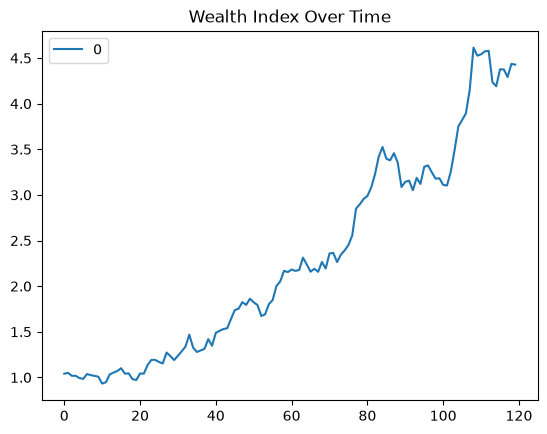

In [11]:
rets = gbm()

wealth_index = (1 + rets).cumprod()

wealth_index.plot(title="Wealth Index Over Time")

In [21]:
def gbm(n_years=10, n_scenarios=50, mu=0.07, sigma=0.15, steps_per_year=12, s_0=100):
    dt = 1 / steps_per_year
    n_steps = n_years * steps_per_year
    rets_p_1 = np.random.normal(loc=((1+mu)**dt), scale=sigma*np.sqrt(dt), size=(n_steps, n_scenarios))
    return s_0*pd.DataFrame(rets_p_1).cumprod()

<Axes: title={'center': 'Wealth Index Over Time'}>

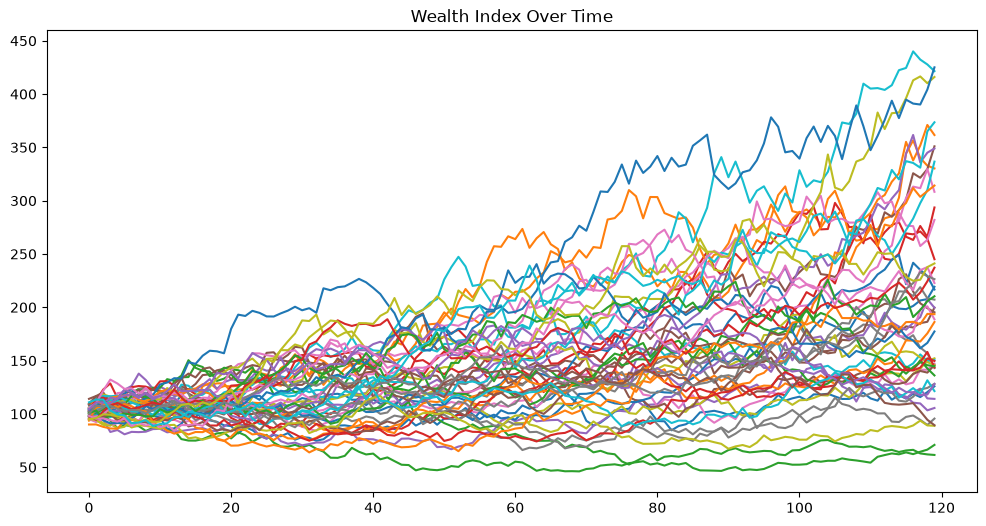

In [39]:
gbm().plot(title="Wealth Index Over Time", legend=False, figsize=(12, 6))

In [31]:
def gbm_prepend(n_years=10, n_scenarios=50, mu=0.07, sigma=0.15, steps_per_year=12, s_0=100):
    dt = 1 / steps_per_year
    n_steps = n_years * steps_per_year
    rets_p_1 = np.random.normal(loc=((1+mu)**dt), scale=sigma*np.sqrt(dt), size=(n_steps, n_scenarios))
    rets_p_1 = pd.concat([pd.DataFrame(np.ones((1,n_scenarios))), pd.DataFrame(rets_p_1)], ignore_index=True)
    return s_0*rets_p_1.cumprod()

<Axes: title={'center': 'Wealth Index Over Time'}>

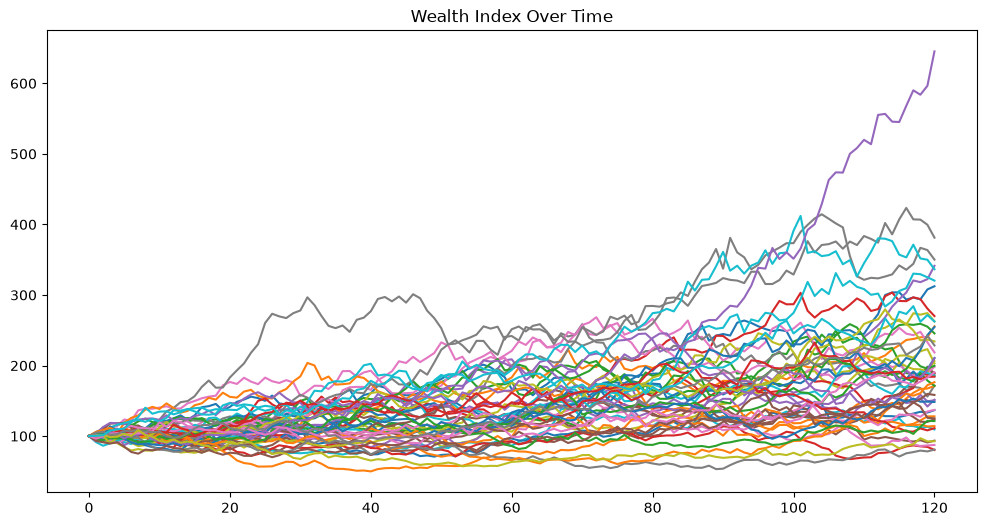

In [47]:
gbm_prepend().plot(title="Wealth Index Over Time", legend=False, figsize=(12, 6))

In [ ]:
import ipywidgets as widgets
# Using widgets to create an interactive plot for the GBM simulation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
n_years = 10
n_scenarios = 10000
mu = 0.07
sigma = 0.15
steps_per_year = 12
s_0 = 100

In [51]:
dt = 1 / steps_per_year
n_steps = n_years * steps_per_year

In [73]:
np.random.seed(42)
Z = np.random.normal(size=(n_steps, n_scenarios))

In [74]:
growth = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

In [75]:
prices = s_0 * np.exp(np.cumsum(growth, axis=0))

In [76]:
prices = np.vstack([np.full((1, n_scenarios), s_0), prices])

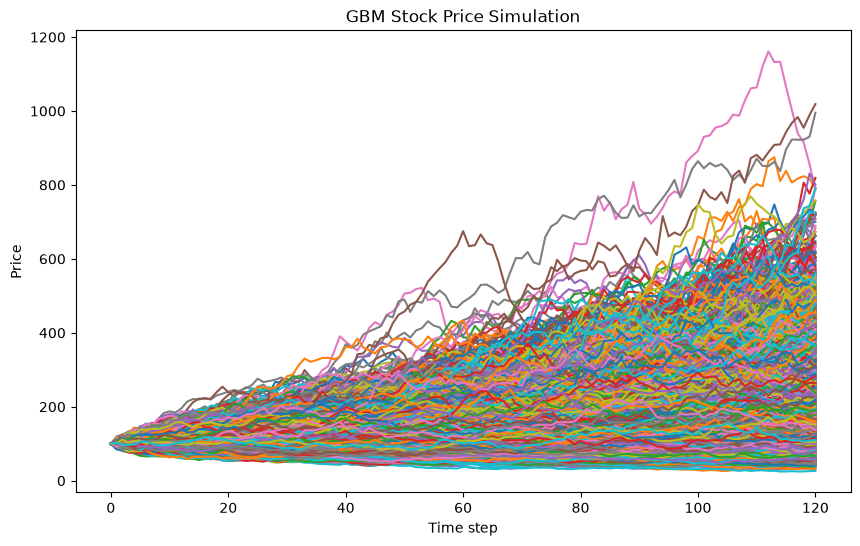

In [77]:
plt.figure(figsize=(10, 6))

plt.plot(prices)

plt.xlabel("Time step")
plt.ylabel("Price")
plt.title("GBM Stock Price Simulation")

plt.show()

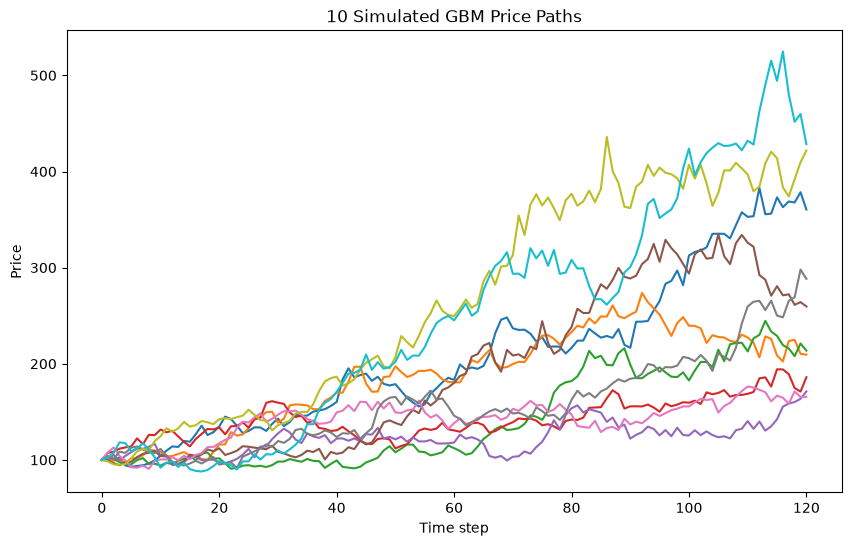

In [78]:
plt.figure(figsize=(10, 6))

plt.plot(prices[:, :10])

plt.xlabel("Time step")
plt.ylabel("Price")
plt.title("10 Simulated GBM Price Paths")
plt.show()

In [79]:
log_returns = np.log(prices[1:] / prices[:-1])

In [80]:
mean_returns = log_returns.mean(axis=1)

In [81]:
mean_return = log_returns.mean()
std_return = log_returns.std()

print("Mean log return:", mean_return)
print("Standard deviation:", std_return)

Mean log return: 0.004845102604746647
Standard deviation: 0.043335729962519075


In [82]:
simple_returns = prices[1:] / prices[:-1] - 1

In [83]:
mean_simple_return = simple_returns.mean()
mean_log_return = log_returns.mean()

print("Mean simple return:", mean_simple_return)
print("Mean log return:", mean_log_return)

Mean simple return: 0.005800837236438952
Mean log return: 0.004845102604746647


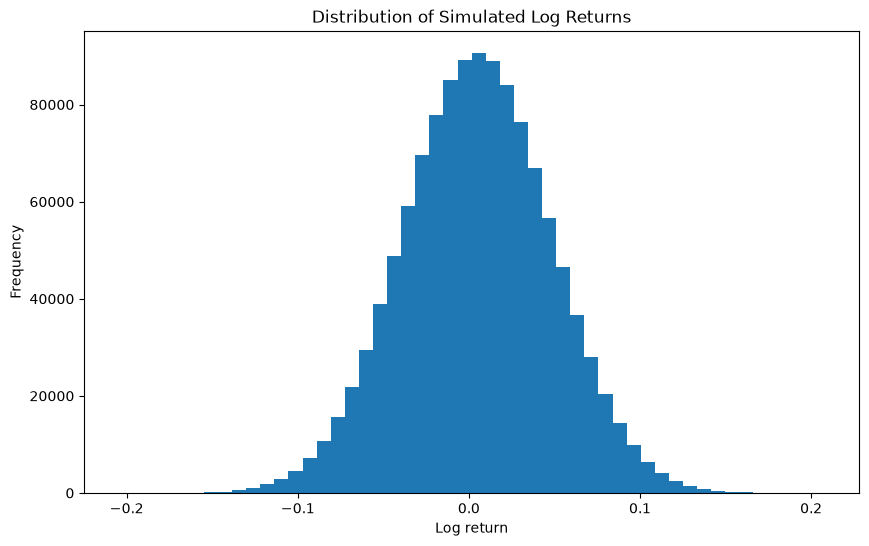

In [84]:
plt.figure(figsize=(10, 6))

plt.hist(log_returns.flatten(), bins=50)

plt.xlabel("Log return")
plt.ylabel("Frequency")
plt.title("Distribution of Simulated Log Returns")
plt.show()

In [85]:
within_one_std = np.abs(log_returns - mean_return) <= std_return

proportion_within_one_std = within_one_std.mean()

print("Proportion within 1 standard deviation:", proportion_within_one_std)

Proportion within 1 standard deviation: 0.6824941666666666


In [86]:
terminal_prices = prices[-1]

print("Mean terminal price:", terminal_prices.mean())
print("Median terminal price:", np.median(terminal_prices))
print("Minimum terminal price:", terminal_prices.min())
print("Maximum terminal price:", terminal_prices.max())

Mean terminal price: 200.0138512393605
Median terminal price: 179.70385766730345
Minimum terminal price: 26.52685226123773
Maximum terminal price: 1018.7299112609884


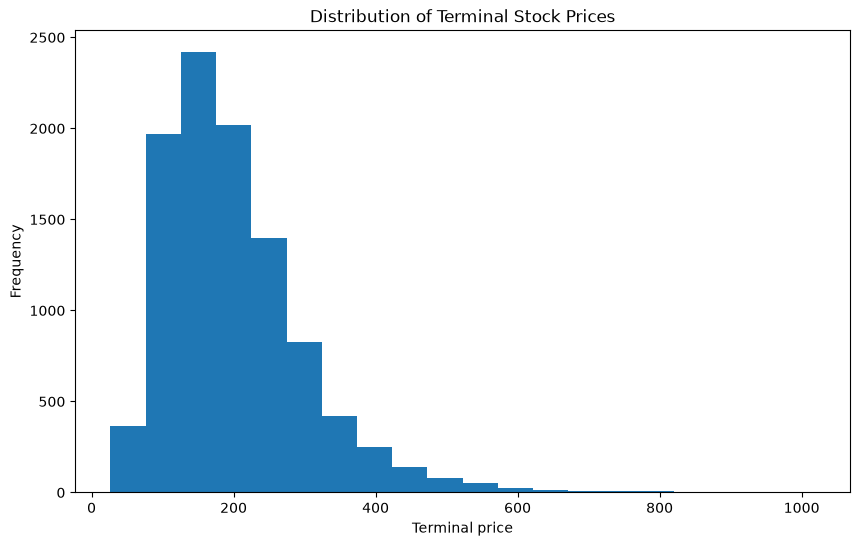

In [87]:
plt.figure(figsize=(10, 6))
plt.hist(terminal_prices, bins=20)
plt.xlabel("Terminal price")
plt.ylabel("Frequency")
plt.title("Distribution of Terminal Stock Prices")

plt.show()

In [88]:
probability_of_loss = np.mean(terminal_prices < s_0)

print("Probability of loss:", probability_of_loss)

Probability of loss: 0.1115


In [89]:
losses = terminal_prices[terminal_prices < s_0]

print("Number of losing scenarios:", len(losses))
print("Average terminal price in losing scenarios:", losses.mean())


Number of losing scenarios: 1115
Average terminal price in losing scenarios: 80.63335082519224


In [90]:
var_95_price = np.percentile(terminal_prices, 5)

var_95_loss = s_0 - var_95_price

print("5th percentile terminal price:", var_95_price)
print("95% VaR:", var_95_loss)

5th percentile terminal price: 81.73076038099744
95% VaR: 18.269239619002562


In [91]:
worst_5_percent = terminal_prices[terminal_prices <= var_95_price]

expected_shortfall = s_0 - worst_5_percent.mean()

print("Expected Shortfall (95%):", expected_shortfall)

Expected Shortfall (95%): 32.1054607841357


In [92]:
terminal_returns = terminal_prices / s_0 - 1

print("Mean terminal return:", terminal_returns.mean())
print("Median terminal return:", np.median(terminal_returns))
print("Minimum terminal return:", terminal_returns.min())
print("Maximum terminal return:", terminal_returns.max())

Mean terminal return: 1.0001385123936049
Median terminal return: 0.7970385766730343
Minimum terminal return: -0.7347314773876227
Maximum terminal return: 9.187299112609884


Text(0.5, 1.0, 'Distribution of Terminal Returns')

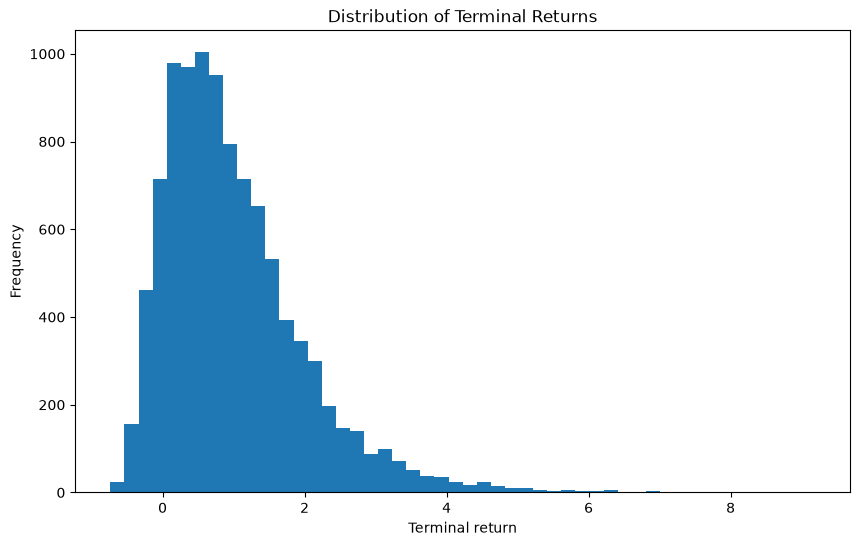

In [93]:
plt.figure(figsize=(10, 6))
plt.hist(terminal_returns, bins=50)
plt.xlabel("Terminal return")
plt.ylabel("Frequency")
plt.title("Distribution of Terminal Returns")

In [94]:
theoretical_mean = (mu - 0.5 * sigma**2) * dt
theoretical_std = sigma * np.sqrt(dt)

print("Simulated mean:", log_returns.mean())
print("Theoretical mean:", theoretical_mean)

print("Simulated standard deviation:", log_returns.std())
print("Theoretical standard deviation:", theoretical_std)

Simulated mean: 0.004845102604746647
Theoretical mean: 0.004895833333333334
Simulated standard deviation: 0.043335729962519075
Theoretical standard deviation: 0.043301270189221926


In [95]:
standard_error = log_returns.std() / np.sqrt(log_returns.size)

print("Standard error of mean log return:", standard_error)

Standard error of mean log return: 3.955992807737367e-05


In [96]:
def simulate_gbm(n_years, n_scenarios, mu, sigma, steps_per_year, s_0):
    dt = 1 / steps_per_year
    n_steps = n_years * steps_per_year

    Z = np.random.normal(size=(n_steps, n_scenarios))

    growth = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

    prices = s_0 * np.exp(np.cumsum(growth, axis=0))

    prices = np.vstack([
        np.full((1, n_scenarios), s_0),
        prices
    ])

    return prices

In [102]:
volatilities = [0.10, 0.15, 0.20, 0.25, 0.30]
var_results = []
es_results = []

for sigma in volatilities:
    prices = simulate_gbm(
        n_years=10,
        n_scenarios=10000,
        mu=0.07,
        sigma=sigma,
        steps_per_year=12,
        s_0=100
    )

    terminal_prices = prices[-1]

    var_95_price = np.percentile(terminal_prices, 5)
    var_95_loss = 100 - var_95_price

    worst_5_percent = terminal_prices[terminal_prices <= var_95_price]
    expected_shortfall = 100 - worst_5_percent.mean()

    var_results.append(var_95_loss)
    es_results.append(expected_shortfall)

In [103]:
es_results

[np.float64(0.05744373925594459),
 np.float64(31.834971248641295),
 np.float64(53.97430687153171),
 np.float64(70.74722586434972),
 np.float64(80.08452247452907)]

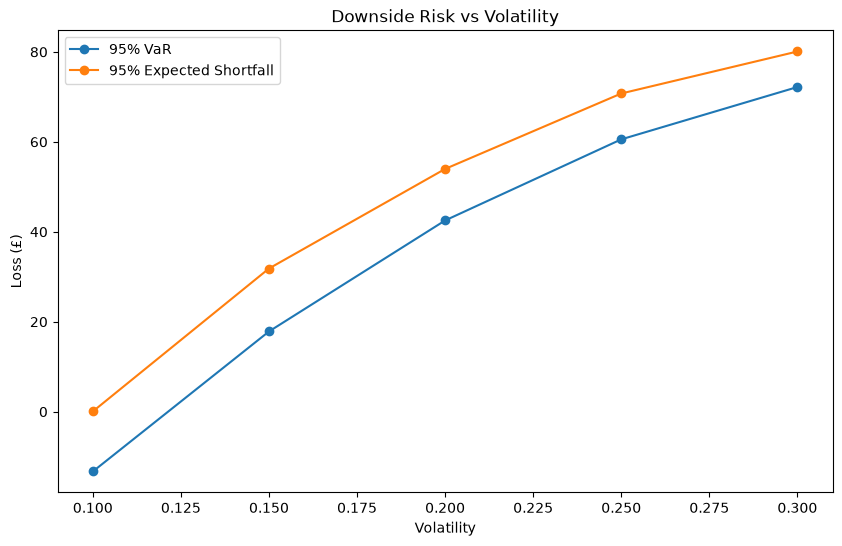

In [105]:
plt.figure(figsize=(10, 6))

plt.plot(volatilities, var_results, marker="o", label="95% VaR")
plt.plot(volatilities, es_results, marker="o", label="95% Expected Shortfall")

plt.xlabel("Volatility")
plt.ylabel("Loss (£)")
plt.title("Downside Risk vs Volatility")
plt.legend()

In [106]:
correlation = np.array([
    [1.0, 0.6],
    [0.6, 1.0]
])

print(correlation)

L = np.linalg.cholesky(correlation)

print(L)

[[1.  0.6]
 [0.6 1. ]]
[[1.  0. ]
 [0.6 0.8]]


In [107]:
Z = np.random.normal(size=(2, 10000))
X = L @ Z
np.corrcoef(X)

array([[1.       , 0.5967893],
       [0.5967893, 1.       ]])

In [15]:
def simulate_correlated_gbm(
    n_years,
    n_scenarios,
    mu,
    sigma,
    correlation,
    steps_per_year,
    s_0
):
    n_assets = len(mu)

    dt = 1 / steps_per_year
    n_steps = n_years * steps_per_year

    L = np.linalg.cholesky(correlation)

    Z = np.random.normal(
        size=(n_assets, n_steps, n_scenarios)
    )

    correlated_Z = L @ Z.reshape(n_assets, -1)
    correlated_Z = correlated_Z.reshape(n_assets, n_steps, n_scenarios)

    growth = (
        (mu[:, None, None] - 0.5 * sigma[:, None, None]**2) * dt
        + sigma[:, None, None] * np.sqrt(dt) * correlated_Z
    )

    prices = s_0[:, None, None] * np.exp(
        np.cumsum(growth, axis=1)
    )

    initial_prices = np.broadcast_to(
        s_0[:, None, None],
        (n_assets, 1, n_scenarios)
    )

    prices = np.concatenate(
        [initial_prices, prices],
        axis=1
    )

    return prices

In [16]:
mu = np.array([0.07, 0.06])
sigma = np.array([0.15, 0.20])

s_0 = np.array([100, 100])

correlation = np.array([
    [1.0, 0.6],
    [0.6, 1.0]
])

In [17]:
np.random.seed(42)

prices = simulate_correlated_gbm(
    n_years=10,
    n_scenarios=10000,
    mu=mu,
    sigma=sigma,
    correlation=correlation,
    steps_per_year=12,
    s_0=s_0
)

[[1.         0.60023837]
 [0.60023837 1.        ]]


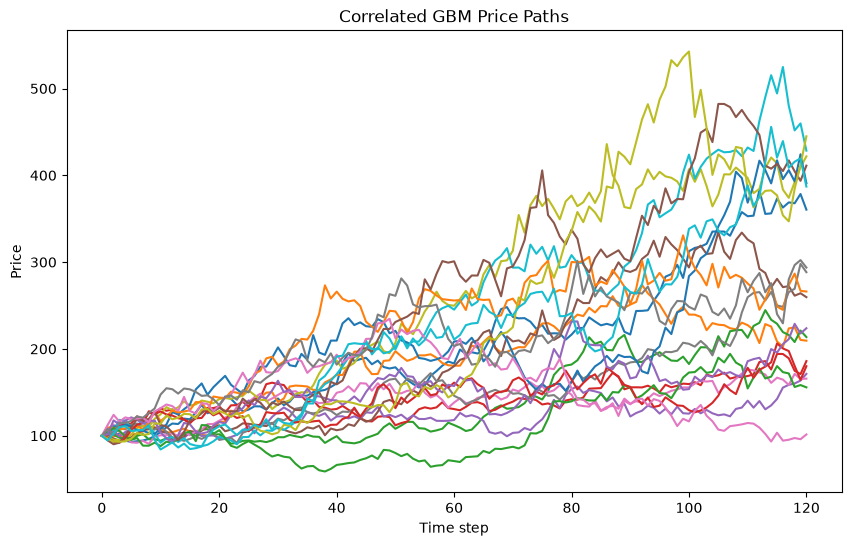

In [20]:
returns = np.log(prices[:, 1:] / prices[:, :-1])

correlation_simulated = np.corrcoef(
    returns[0].flatten(),
    returns[1].flatten()
)

print(correlation_simulated)

plt.figure(figsize=(10, 6))

plt.plot(prices[0, :, :10])
plt.plot(prices[1, :, :10])

plt.xlabel("Time step")
plt.ylabel("Price")
plt.title("Correlated GBM Price Paths")
plt.show()

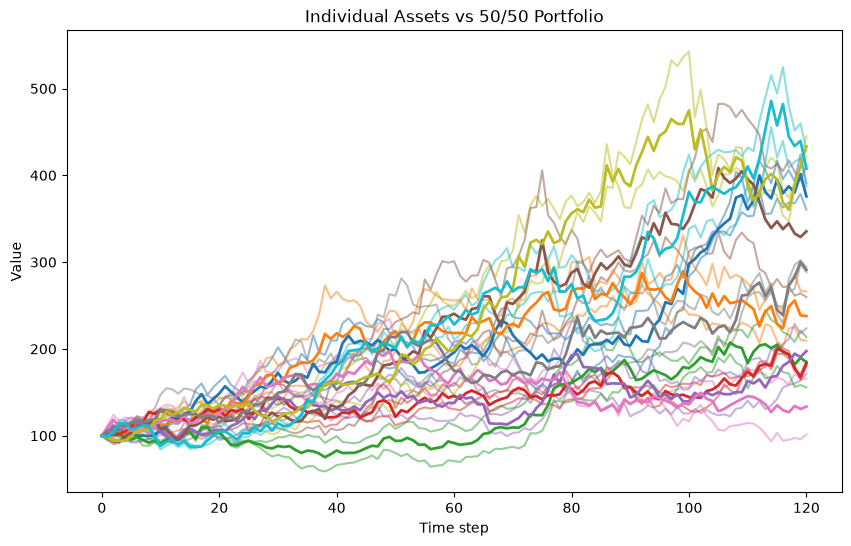

In [116]:
weights = np.array([0.5, 0.5])

portfolio_prices = np.sum(
    weights[:, None, None] * prices,
    axis=0
)

plt.figure(figsize=(10, 6))

plt.plot(prices[0, :, :10], alpha=0.5)
plt.plot(prices[1, :, :10], alpha=0.5)
plt.plot(portfolio_prices[:, :10], linewidth=2)

plt.xlabel("Time step")
plt.ylabel("Value")
plt.title("Individual Assets vs 50/50 Portfolio")
plt.show()


In [118]:
portfolio_returns = np.log(
    portfolio_prices[1:] / portfolio_prices[:-1]
)

portfolio_volatility = portfolio_returns.std() * np.sqrt(12)

print("Portfolio annualised volatility:", portfolio_volatility)

covariance = np.outer(sigma, sigma) * correlation

portfolio_variance = weights @ covariance @ weights

portfolio_volatility_theoretical = np.sqrt(portfolio_variance)

print("Theoretical portfolio volatility:", portfolio_volatility_theoretical)

Portfolio annualised volatility: 0.1564978242098874
Theoretical portfolio volatility: 0.15692354826475216


Text(0.5, 1.0, 'Portfolio Volatility vs Asset Allocation')

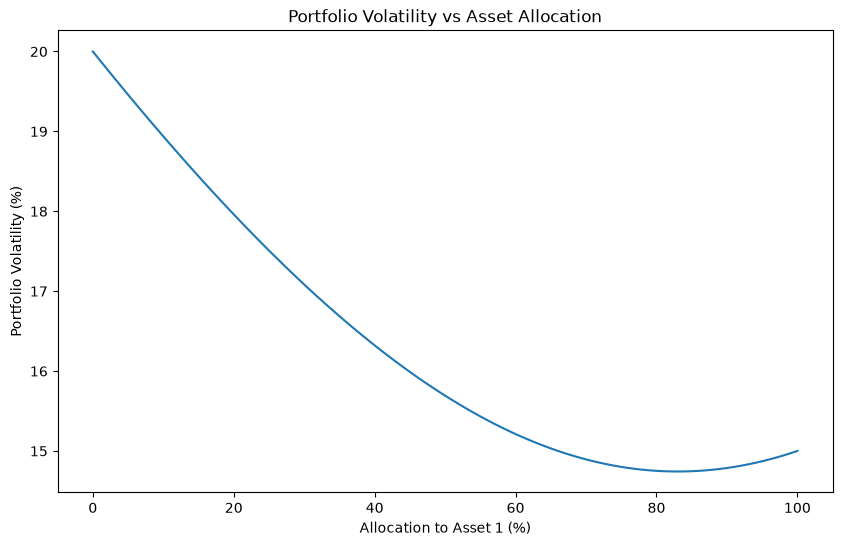

In [119]:
weights_asset_1 = np.linspace(0, 1, 101)

portfolio_volatilities = []

for w1 in weights_asset_1:
    weights = np.array([w1, 1 - w1])

    portfolio_variance = weights @ covariance @ weights
    portfolio_volatility = np.sqrt(portfolio_variance)

    portfolio_volatilities.append(portfolio_volatility)

plt.figure(figsize=(10, 6))

plt.plot(
    weights_asset_1 * 100,
    np.array(portfolio_volatilities) * 100
)

plt.xlabel("Allocation to Asset 1 (%)")
plt.ylabel("Portfolio Volatility (%)")
plt.title("Portfolio Volatility vs Asset Allocation")

In [120]:
min_index = np.argmin(portfolio_volatilities)

optimal_weight_1 = weights_asset_1[min_index]
optimal_weight_2 = 1 - optimal_weight_1
minimum_volatility = portfolio_volatilities[min_index]

print("Asset 1 weight:", optimal_weight_1)
print("Asset 2 weight:", optimal_weight_2)
print("Minimum volatility:", minimum_volatility)

Asset 1 weight: 0.8300000000000001
Asset 2 weight: 0.16999999999999993
Minimum volatility: 0.147430831239602


In [121]:
covariance = np.outer(sigma, sigma) * correlation

sigma_1_sq = covariance[0, 0]
sigma_2_sq = covariance[1, 1]
sigma_12 = covariance[0, 1]

optimal_weight_1 = (
    sigma_2_sq - sigma_12
) / (
    sigma_1_sq + sigma_2_sq - 2 * sigma_12
)

optimal_weight_2 = 1 - optimal_weight_1

optimal_weights = np.array([
    optimal_weight_1,
    optimal_weight_2
])

minimum_variance = optimal_weights @ covariance @ optimal_weights
minimum_volatility = np.sqrt(minimum_variance)

print("Optimal weights:", optimal_weights)
print("Minimum volatility:", minimum_volatility)

Optimal weights: [0.83018868 0.16981132]
Minimum volatility: 0.1474308280401483


Optimal weights: [0.83018868 0.16981132]
Mean terminal value: 196.83024555799267
Median terminal value: 177.91593811582027
95% VaR: 18.684135446224488
95% Expected Shortfall: 31.947645166435976


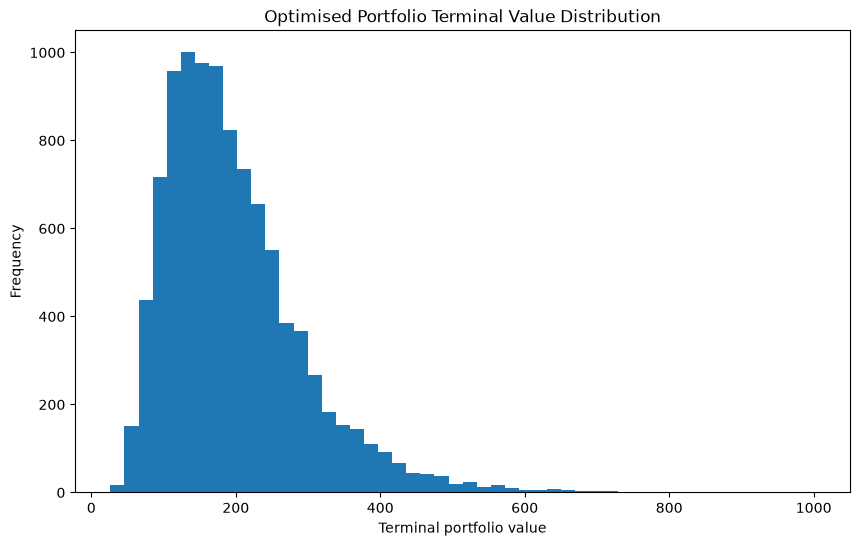

In [122]:
# Optimised portfolio

optimal_portfolio_prices = np.sum(
    optimal_weights[:, None, None] * prices,
    axis=0
)

terminal_portfolio_values = optimal_portfolio_prices[-1]

# Terminal returns
portfolio_terminal_returns = (
    terminal_portfolio_values / 100 - 1
)

# VaR
var_95_portfolio_value = np.percentile(
    terminal_portfolio_values, 5
)

var_95_portfolio = 100 - var_95_portfolio_value

# Expected Shortfall
worst_5_percent = terminal_portfolio_values[
    terminal_portfolio_values <= var_95_portfolio_value
]

expected_shortfall_portfolio = (
    100 - worst_5_percent.mean()
)

print("Optimal weights:", optimal_weights)
print("Mean terminal value:", terminal_portfolio_values.mean())
print("Median terminal value:", np.median(terminal_portfolio_values))
print("95% VaR:", var_95_portfolio)
print("95% Expected Shortfall:", expected_shortfall_portfolio)

plt.figure(figsize=(10, 6))

plt.hist(terminal_portfolio_values, bins=50)

plt.xlabel("Terminal portfolio value")
plt.ylabel("Frequency")
plt.title("Optimised Portfolio Terminal Value Distribution")
plt.show()

In [123]:
import yfinance as yf

tickers = ["SPY", "TLT"]

data = yf.download(
    tickers,
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=True
)

prices = data["Close"]

print(prices.head())

returns = np.log(prices / prices.shift(1)).dropna()

print(returns.head())

mu = returns.mean() * 252
sigma = returns.std() * np.sqrt(252)

correlation = returns.corr()

print("Annualised returns:")
print(mu)

print("\nAnnualised volatility:")
print(sigma)

print("\nCorrelation matrix:")
print(correlation)

[*********************100%***********************]  2 of 2 completed

Ticker             SPY        TLT
Date                             
2015-01-02  169.267532  91.935226
2015-01-05  166.210587  93.379410
2015-01-06  164.645065  95.061790
2015-01-07  166.696777  94.874100
2015-01-08  169.654800  93.617668
Ticker           SPY       TLT
Date                          
2015-01-05 -0.018225  0.015587
2015-01-06 -0.009464  0.017856
2015-01-07  0.012384 -0.001976
2015-01-08  0.017589 -0.013332
2015-01-09 -0.008046  0.010893
Annualised returns:
Ticker
SPY    0.126287
TLT   -0.007620
dtype: float64

Annualised volatility:
Ticker
SPY    0.178309
TLT    0.150374
dtype: float64

Correlation matrix:
Ticker       SPY       TLT
Ticker                    
SPY     1.000000 -0.184282
TLT    -0.184282  1.000000


In [124]:
covariance = np.outer(
    sigma.values,
    sigma.values
) * correlation.values

print("Covariance matrix:")
print(covariance)


sigma_1_sq = covariance[0, 0]
sigma_2_sq = covariance[1, 1]
sigma_12 = covariance[0, 1]

optimal_weight_spy = (
    sigma_2_sq - sigma_12
) / (
    sigma_1_sq + sigma_2_sq - 2 * sigma_12
)

optimal_weight_tlt = 1 - optimal_weight_spy

optimal_weights = np.array([
    optimal_weight_spy,
    optimal_weight_tlt
])

minimum_variance = (
    optimal_weights @ covariance @ optimal_weights
)

minimum_volatility = np.sqrt(minimum_variance)

print("Optimal weights:", optimal_weights)
print("Minimum volatility:", minimum_volatility)

Covariance matrix:
[[ 0.03179414 -0.00494117]
 [-0.00494117  0.02261242]]
Optimal weights: [0.42859019 0.57140981]
Minimum volatility: 0.10393855127152901


Annualised return: 0.04977142171785656
Annualised volatility: 0.10393855127152898
Sharpe ratio: 0.4788542952444444


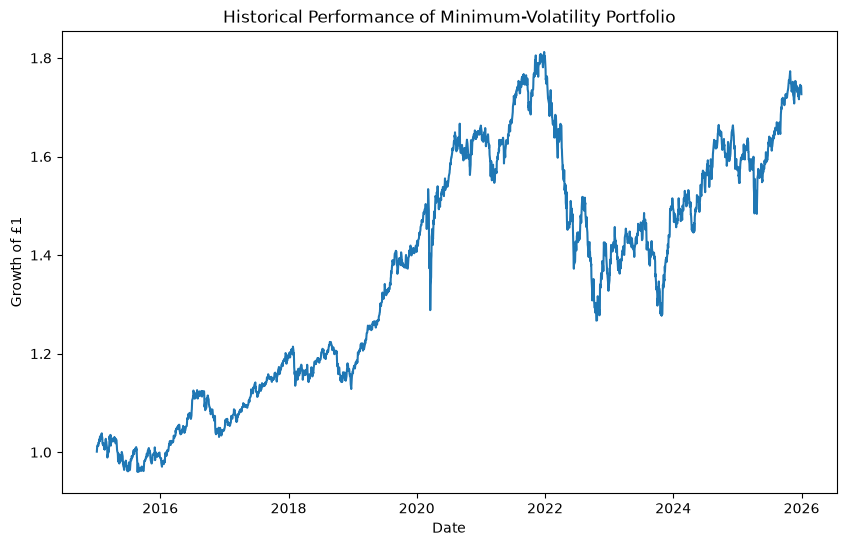

In [125]:
weights = optimal_weights

portfolio_returns = returns @ weights

cumulative_returns = np.exp(
    portfolio_returns.cumsum()
)

plt.figure(figsize=(10, 6))
plt.plot(cumulative_returns)

plt.xlabel("Date")
plt.ylabel("Growth of £1")
plt.title("Historical Performance of Minimum-Volatility Portfolio")

annualised_return = portfolio_returns.mean() * 252
annualised_volatility = portfolio_returns.std() * np.sqrt(252)

sharpe_ratio = annualised_return / annualised_volatility

print("Annualised return:", annualised_return)
print("Annualised volatility:", annualised_volatility)
print("Sharpe ratio:", sharpe_ratio)

Maximum drawdown: -0.3008602692957486


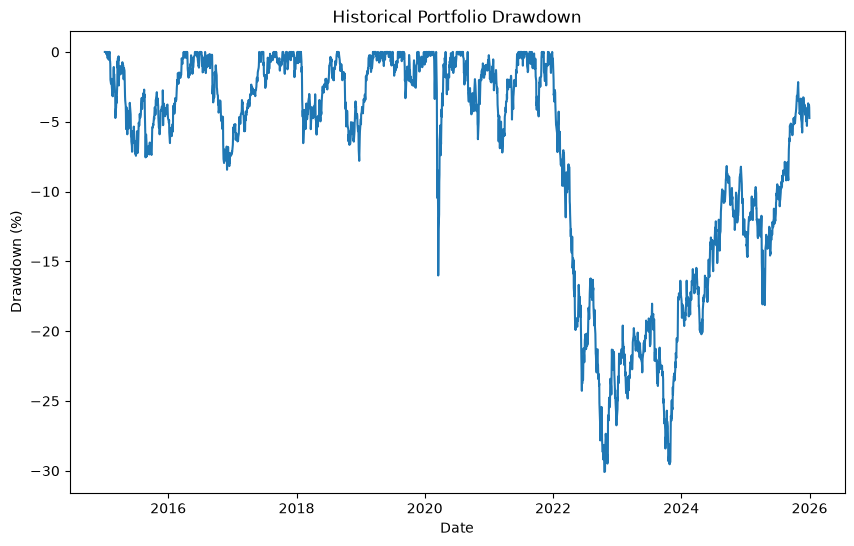

Maximum drawdowns:
{'SPY': np.float64(-0.3371728189633809), 'TLT': np.float64(-0.4835115911593659)}
Portfolio: -0.3008602692957486


In [126]:
wealth = np.exp(portfolio_returns.cumsum())

running_max = np.maximum.accumulate(wealth)

drawdown = wealth / running_max - 1

max_drawdown = drawdown.min()

print("Maximum drawdown:", max_drawdown)

plt.figure(figsize=(10, 6))

plt.plot(drawdown * 100)

plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.title("Historical Portfolio Drawdown")
plt.show()

individual_drawdowns = {}

for ticker in returns.columns:
    wealth_asset = np.exp(returns[ticker].cumsum())
    running_max_asset = np.maximum.accumulate(wealth_asset)
    drawdown_asset = wealth_asset / running_max_asset - 1

    individual_drawdowns[ticker] = drawdown_asset.min()

print("Maximum drawdowns:")
print(individual_drawdowns)
print("Portfolio:", max_drawdown)

In [127]:
split_date = "2022-01-01"

train_returns = returns.loc[returns.index < split_date]
test_returns = returns.loc[returns.index >= split_date]

train_sigma = train_returns.std() * np.sqrt(252)
train_correlation = train_returns.corr()

train_covariance = np.outer(
    train_sigma.values,
    train_sigma.values
) * train_correlation.values

sigma_1_sq = train_covariance[0, 0]
sigma_2_sq = train_covariance[1, 1]
sigma_12 = train_covariance[0, 1]

train_weight_1 = (
    sigma_2_sq - sigma_12
) / (
    sigma_1_sq + sigma_2_sq - 2 * sigma_12
)

train_weights = np.array([
    train_weight_1,
    1 - train_weight_1
])

print("Training-period weights:", train_weights)

Training-period weights: [0.41644888 0.58355112]


In [128]:
test_portfolio_returns = test_returns @ train_weights

test_annualised_return = test_portfolio_returns.mean() * 252
test_annualised_volatility = test_portfolio_returns.std() * np.sqrt(252)

print("Test annualised return:", test_annualised_return)
print("Test annualised volatility:", test_annualised_volatility)

Test annualised return: -0.013450306695382573
Test annualised volatility: 0.12765014212426617


In [129]:
import statsmodels.api as sm

X = returns["SPY"]
y = returns["TLT"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    TLT   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     97.13
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           1.52e-22
Time:                        13:03:21   Log-Likelihood:                 9008.0
No. Observations:                2765   AIC:                        -1.801e+04
Df Residuals:                    2763   BIC:                        -1.800e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.765e-05      0.000      0.269      0.7

In [130]:
import pandas_datareader.data as web

ff = web.DataReader(
    "F-F_Research_Data_Factors_daily",
    "famafrench",
    start="2015-01-01",
    end="2026-01-01"
)

factor_data = ff[0]

print(factor_data.head())

            Mkt-RF   SMB   HML   RF
Date                               
2015-01-02   -0.12 -0.59  0.12  0.0
2015-01-05   -1.84  0.33 -0.68  0.0
2015-01-06   -1.03 -0.80 -0.29  0.0
2015-01-07    1.19  0.20 -0.67  0.0
2015-01-08    1.81 -0.11 -0.29  0.0


In [1]:

import os
os.chdir("/Users/DDR/QuantitativePortfolioAnalysis")

print(os.getcwd())


/Users/DDR/QuantitativePortfolioAnalysis


In [7]:
print(os.listdir())

['README.md', '.gitignore', '.venv', '.git', 'notebooks', 'src']


In [10]:
from src.simulation import simulate_gbm

np.random.seed(42)

prices_test = simulate_gbm(
    n_years=10,
    n_scenarios=10000,
    mu=0.07,
    sigma=0.15,
    steps_per_year=12,
    s_0=100
)

print(prices_test.shape)

(121, 10000)


In [22]:
import yfinance as yf
import numpy as np
import pandas as pd

tickers = ["SPY", "TLT"]

data = yf.download(
    tickers,
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=True
)

prices = data["Close"]

returns = np.log(
    prices / prices.shift(1)
).dropna()

print(returns.head())
print(type(returns))
print(returns.columns)

[*********************100%***********************]  2 of 2 completed

Ticker           SPY       TLT
Date                          
2015-01-05 -0.018225  0.015586
2015-01-06 -0.009464  0.017857
2015-01-07  0.012384 -0.001977
2015-01-08  0.017589 -0.013331
2015-01-09 -0.008046  0.010893
<class 'pandas.DataFrame'>
Index(['SPY', 'TLT'], dtype='str', name='Ticker')


In [23]:
from src.factors import run_factor_regression

asset_returns = returns["TLT"]

factor_returns = returns[["SPY"]]

model = run_factor_regression(
    asset_returns,
    factor_returns
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    TLT   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     97.13
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           1.52e-22
Time:                        12:14:23   Log-Likelihood:                 9008.0
No. Observations:                2765   AIC:                        -1.801e+04
Df Residuals:                    2763   BIC:                        -1.800e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.765e-05      0.000      0.269      0.7